In [1]:
"https://drive.google.com/file/d/1BtbX60xWjVSuka1ap7oqnivAXodWWjSL/view?usp=sharing"
file_id = "1BtbX60xWjVSuka1ap7oqnivAXodWWjSL"
url=f"https://drive.google.com/uc?id={file_id}"


In [2]:
# Step 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# NLP Libraries
import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud

# ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Download stopwords (first time only)
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
df = pd.read_csv(url, sep="\t")
df

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."
...,...,...
9995,pos,A revelation of life in small town America in ...
9996,pos,Great biography of a very interesting journali...
9997,neg,Interesting Subject; Poor Presentation: You'd ...
9998,neg,Don't buy: The box looked used and it is obvio...


In [4]:
print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())


First 5 Rows:
  label                                             review
0   pos  Stuning even for the non-gamer: This sound tra...
1   pos  The best soundtrack ever to anything.: I'm rea...
2   pos  Amazing!: This soundtrack is my favorite music...
3   pos  Excellent Soundtrack: I truly like this soundt...
4   pos  Remember, Pull Your Jaw Off The Floor After He...

Dataset Shape:
(10000, 2)

Column Names:
Index(['label', 'review'], dtype='object')

Missing Values:
label     0
review    0
dtype: int64


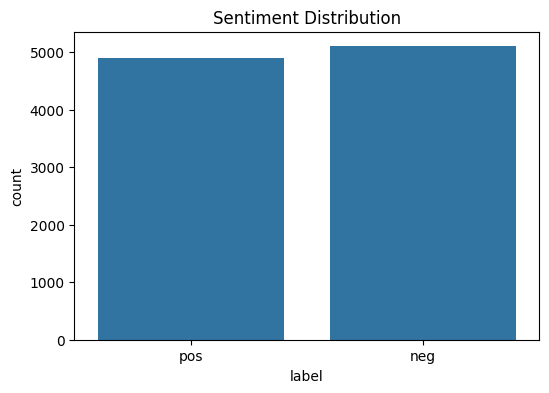

In [5]:
# Step 4: Exploratory Data Analysis (EDA)
# Sentiment Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title("Sentiment Distribution")
plt.show()

In [6]:
# Step 5: Text Preprocessing
stop_words = set(stopwords.words('english'))
ps = PorterStemmer()

def clean_text(text):
    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra spaces
    text = text.strip()

    # Tokenization + Stopword Removal + Stemming
    words = text.split()
    words = [ps.stem(word) for word in words if word not in stop_words]

    return " ".join(words)

# Apply cleaning
df['clean_review'] = df['review'].apply(clean_text)

print("\nCleaned Reviews Sample:")
print(df[['review', 'clean_review']].head())



Cleaned Reviews Sample:
                                              review  \
0  Stuning even for the non-gamer: This sound tra...   
1  The best soundtrack ever to anything.: I'm rea...   
2  Amazing!: This soundtrack is my favorite music...   
3  Excellent Soundtrack: I truly like this soundt...   
4  Remember, Pull Your Jaw Off The Floor After He...   

                                        clean_review  
0  stune even nongam sound track beauti paint sen...  
1  best soundtrack ever anyth im read lot review ...  
2  amaz soundtrack favorit music time hand intens...  
3  excel soundtrack truli like soundtrack enjoy v...  
4  rememb pull jaw floor hear youv play game know...  


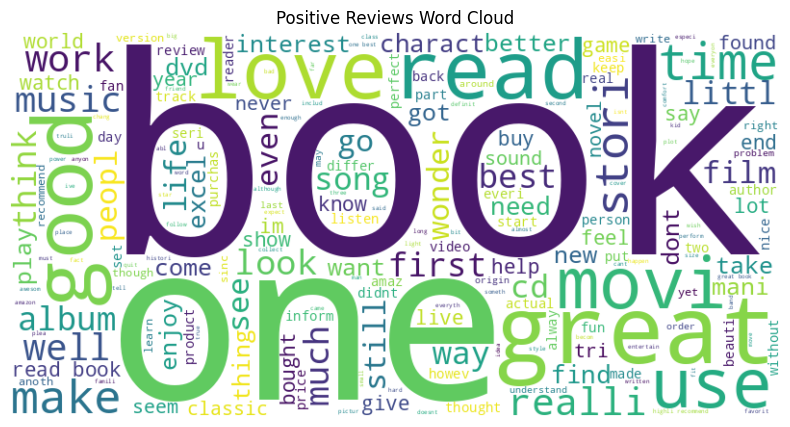

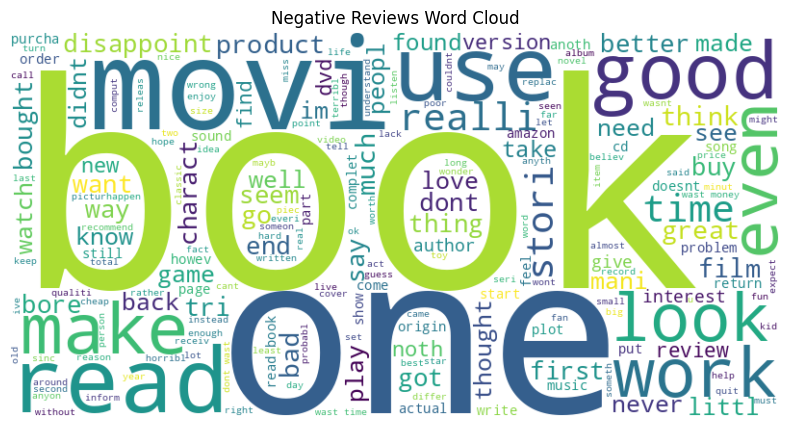

In [7]:
# Step 6: Word Clouds

# Positive Reviews
positive_text = " ".join(df[df['label'] == 'pos']['clean_review'])

plt.figure(figsize=(10,5))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Positive Reviews Word Cloud")
plt.show()


# Negative Reviews
negative_text = " ".join(df[df['label'] == 'neg']['clean_review'])

plt.figure(figsize=(10,5))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(negative_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Negative Reviews Word Cloud")
plt.show()



In [8]:
# Step 7: Convert Labels to Numeric
df['label_num'] = df['label'].map({
    'pos': 1,
    'neg': 0
})


In [9]:
# Step 8: Feature Extraction using TF-IDF

X = df['clean_review']
y = df['label_num']

tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(X)

print("\nTF-IDF Shape:")
print(X_tfidf.shape)


TF-IDF Shape:
(10000, 5000)


In [16]:
# Step 8A: Advanced Embedding using Word2Vec
!pip install gensim
from gensim.models import Word2Vec

# Tokenize cleaned reviews for Word2Vec
tokenized_reviews = [text.split() for text in df['clean_review']]

# Train Word2Vec Model
w2v_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

print("Word2Vec model trained successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 22.0 MB/s eta 0:00:00
Word2Vec model trained successfully!


In [17]:
# Function to average word vectors for each review

def get_avg_word2vec(tokens, model, vector_size):
    vectors = []

    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(vector_size)

    return np.mean(vectors, axis=0)


# Convert all reviews into vectors
X_w2v = np.array([
    get_avg_word2vec(text.split(), w2v_model, 100)
    for text in df['clean_review']
])

print("Word2Vec Feature Shape:", X_w2v.shape)

Word2Vec Feature Shape: (10000, 100)


In [18]:
# Train-test split for Word2Vec features

X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_w2v,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
# Logistic Regression using Word2Vec Features

lr_w2v = LogisticRegression()

lr_w2v.fit(X_train_w2v, y_train_w2v)

y_pred_w2v = lr_w2v.predict(X_test_w2v)

print("\n===== Word2Vec + Logistic Regression Results =====")
print("Accuracy:", accuracy_score(y_test_w2v, y_pred_w2v))
print("\nClassification Report:")
print(classification_report(y_test_w2v, y_pred_w2v))


===== Word2Vec + Logistic Regression Results =====
Accuracy: 0.7345

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.76      0.75      1037
           1       0.73      0.71      0.72       963

    accuracy                           0.73      2000
   macro avg       0.73      0.73      0.73      2000
weighted avg       0.73      0.73      0.73      2000



In [10]:
# Step 9: Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=42
)


===== Logistic Regression Results =====
Accuracy: 0.8415

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1037
           1       0.83      0.84      0.84       963

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



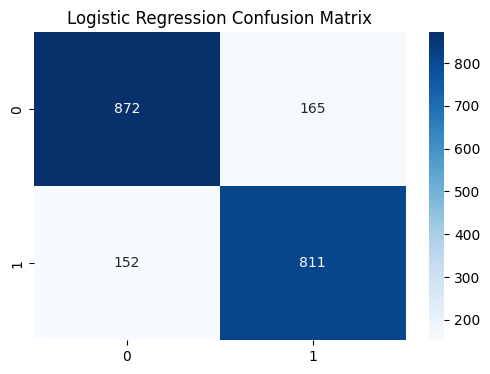

In [11]:
# Step 10: Model 1 - Logistic Regression

lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("\n===== Logistic Regression Results =====")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr),
            annot=True,
            fmt='d',
            cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()



Cross Validation Accuracy Scores:
[0.8465 0.8235 0.8195 0.823  0.8505]

Mean CV Accuracy:
0.8326

===== SVM Results =====
Accuracy: 0.8335

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1037
           1       0.82      0.83      0.83       963

    accuracy                           0.83      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.83      0.83      0.83      2000



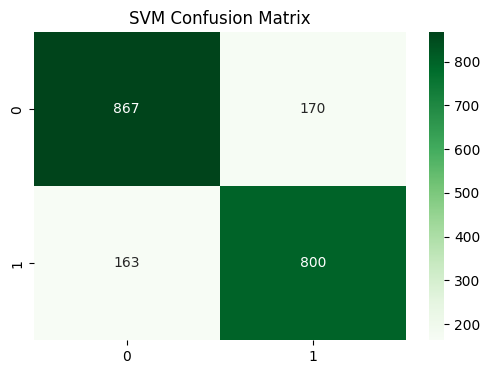

In [12]:
# Step 11: Model 2 - SVM
# Step 12: Cross Validation

cv_scores = cross_val_score(
    LogisticRegression(),
    X_tfidf,
    y,
    cv=5,
    scoring='accuracy'
)

print("\nCross Validation Accuracy Scores:")
print(cv_scores)

print("\nMean CV Accuracy:")
print(cv_scores.mean())



svm = LinearSVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("\n===== SVM Results =====")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm),
            annot=True,
            fmt='d',
            cmap='Greens')
plt.title("SVM Confusion Matrix")
plt.show()


In [22]:
# Step 13: Final Model Comparison
print("\n========== Final Comparison ==========")

print("TF-IDF + Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("TF-IDF + SVM Accuracy:",
      accuracy_score(y_test, y_pred_svm))

print("Word2Vec + Logistic Regression Accuracy:",
      accuracy_score(y_test_w2v, y_pred_w2v))

print("\nBest Model: Choose based on Accuracy + F1-score")


========== Final Comparison ==========
TF-IDF + Logistic Regression Accuracy: 0.8415
TF-IDF + SVM Accuracy: 0.8335
Word2Vec + Logistic Regression Accuracy: 0.7345

Best Model: Choose based on Accuracy + F1-score
